### An Invitation to Analytic Combinatorics - Lecture 3

This SageMath notebook works contains the Sage code presented in Lecture 3 of the MPI Lecture Series presented by Stephen Melczer in June 2026.

### Part 1: Multivariate Generating Functions and Diagonals

In [1]:
# We can define multivariate series in Sage
# However this enumerates by total degree
S.<u, z> = LazyPowerSeriesRing(QQ)
B = S.undefined()
B.define(u*z + 2*z*B + z*B^2)
B

u*z + 2*u*z^2 + 4*u*z^3 + (u^2*z^3+8*u*z^4) + (6*u^2*z^4+16*u*z^5) + O(u,z)^7

In [2]:
# Instead define series in z whose coeffs are polys in u
S.<u> = QQ['u']
T.<z> = LazyPowerSeriesRing(S)
B = T.undefined()
B.define(u*z + 2*z*B + z*B^2)
B

u*z + 2*u*z^2 + ((u^2+4*u)*z^3) + ((6*u^2+8*u)*z^4) + ((2*u^3+24*u^2+16*u)*z^5) + ((20*u^3+80*u^2+32*u)*z^6) + O(z^7)

In [3]:
# There are four trees with size 4 and one leaf, and one tree with size 4 and two leaves
print(B[3])

u^2 + 4*u


In [4]:
# Print out the trees and their leaf counts
def count_leaves(t): return str(t).count('[., .]')
print(ascii_art(list(BinaryTrees(3))))
print([count_leaves(k) for k in BinaryTrees(3)])

[ o    , o  ,   o  ,   o,     o ]
[  \      \    / \    /      /  ]
[   o      o  o   o  o      o   ]
[    \    /           \    /    ]
[     o  o             o  o     ]
[1, 1, 2, 1, 1]


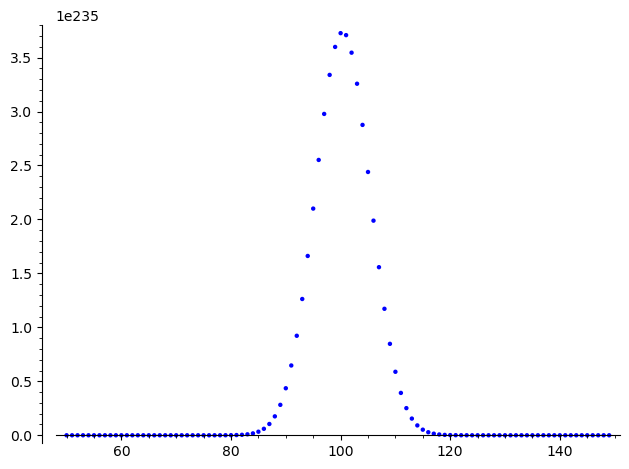

In [5]:
# Number of leaves approaches a normal distribution
point([[k,B[400][k]] for k in range(50,150)])

In [6]:
# Solve quadratic for B(u,z)
var('u z B')
solve(u*z + 2*z*B + z*B^2 - B,B)

[B == -1/2*(2*z + sqrt(-4*(u - 1)*z^2 - 4*z + 1) - 1)/z,
 B == -1/2*(2*z - sqrt(-4*(u - 1)*z^2 - 4*z + 1) - 1)/z]

In [7]:
# Picking the correct root
B = -1/2*(2*z + sqrt(-4*(u - 1)*z^2 - 4*z + 1) - 1)/z
B.series(z,4)

(u)*z + (2*u)*z^2 + ((u - 1)*u + 5*u)*z^3 + Order(z^4)

In [8]:
# Coin change problem
S.<a,b,c,d,e,f,g,h> = QQ['a,b,c,d,e,f,g,h']
T.<z> = LazyPowerSeriesRing(S)
F = 1/(1-a*z)/(1-b*z^2)/(1-c*z^5)/(1-d*z^10)/(1-e*z^20)/(1-f*z^50)/(1-g*z^100)/(1-h*z^200)
F[10]

a^10 + a^8*b + a^6*b^2 + a^4*b^3 + a^2*b^4 + a^5*c + b^5 + a^3*b*c + a*b^2*c + c^2 + d

In [9]:
# Expanding 1/(1-x-y)
A.<x,y> = QQ[['x,y']]
1/(1-x-y + O(x^4))

1 + x + y + x^2 + 2*x*y + y^2 + x^3 + 3*x^2*y + 3*x*y^2 + y^3 + O(x, y)^4

In [10]:
# Asymptotics of N-SE-SW walks in N^2 using diagonal expression
# NOTE: To run this you must install the sage_acsv package 
# from https://github.com/ACSVMath/sage_acsv
from sage_acsv import diagonal_asymptotics_combinatorial as diagonal
var('x,y,z')
F = (1 + x)*(2*z*x^2*y^2 + 2*z*y^2 - 1)/((-1 + y)*(z*x^2*y^2 + z*y^2 + z*x - 1)*(z*x^2*y^2 + z*y^2 - 1))
diagonal(F, expansion_precision=2)

0.9705627484771406?/pi*2.828427124746190?^n*n^(-2)*(e^(I*arg(-1)))^n + 32.97056274847714?/pi*2.828427124746190?^n*n^(-2) + O(2.828427124746190?^n*n^(-3))

In [11]:
# CLT for divisions in polynomial EEA over finite field
# Code to generate animation for CLT can be found on
# https://github.com/smelczer/enumeration-notebooks/blob/main/Chapter%201%20-%20Introduction.ipynb
from sage_acsv import central_limit_theorem_combinatorial as CLT
CLT(1/(1-3*z-6*u*z), z, as_symbolic=True)

3/2*9^n*e^(1/4*(6*n - 9*s0)*(-2/3*n + s0)/n)/(sqrt(pi)*sqrt(n))

### Part 2: Complex Analysis of Multivariate Rational Functions

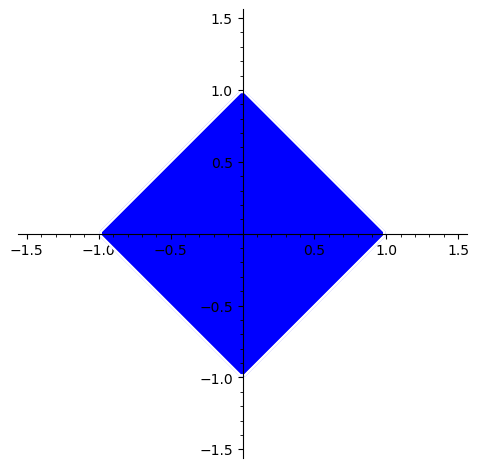

In [12]:
# Plot domain of absolute convergence of 1/(1-x-y)
region_plot(
    abs(x) + abs(y) < 1, 
    (x, -1.5, 1.5), 
    (y, -1.5, 1.5), 
)

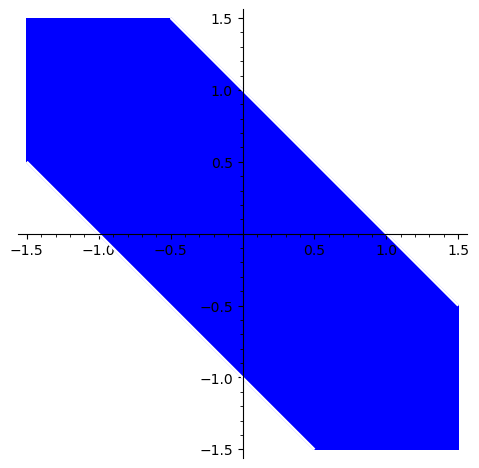

In [13]:
# Plot incorrect (naive) region of convergence of 1/(1-x-y)
region_plot(
    abs(x+y) < 1, 
    (x, -1.5, 1.5), 
    (y, -1.5, 1.5), 
)

In [14]:
var('x,y,r,t')
import numpy as np

# Amoeba plotting code (by naively plotting many test points)
def plot_amoeba(f, n_radius=100, n_theta=100, xmin=-5, xmax=5, ymin=-5, ymax=5):
    """
    Plots the 2D polynomial amoeba of a given two-variable symbolic polynomial f.
    Use numpy to find roots for efficiency.
    """
    gens = f.variables()
        
    if len(gens) != 2:
        raise ValueError("Enter a bivariate polynomial.")
    
    # Cast f into a Polynomial Ring with complex floating point coefficients
    x_name, y_name = str(gens[0]), str(gens[1])
    R = PolynomialRing(CC, names=[x_name, y_name])
    x_poly, y_poly = R.gens()
    f_poly = R(f)
    
    # f_y is a polynomial in y_poly with coefficients in CC[x_poly]
    # f_x is a polynomial in x_poly with coefficients in CC[y_poly]
    coeffs_y = f_poly.polynomial(y_poly).list()
    coeffs_x = f_poly.polynomial(x_poly).list()

    # Use a fixed small value log(almost_zero) to represent -infinity in the amoeba
    almost_zero = 1e-14 
    points = []

    # Pre-generate the grid using meshgrid (vectorization)
    log_r_x = np.linspace(xmin, xmax, n_radius)
    theta = np.linspace(0, 2 * np.pi, n_theta)
    
    LogR, Theta_grid = np.meshgrid(log_r_x, theta)
    LogR_flat = LogR.flatten()
    Z_flat = np.exp(LogR_flat) * np.exp(1j * Theta_grid.flatten())

    # Fix x = r*exp(i*theta) and solve for y
    # Pre-allocate array for evaluated polynomials. Shape: (num_points, degree+1)
    C_eval_y = np.zeros((len(Z_flat), len(coeffs_y)), dtype=complex)
    
    for idx, c in enumerate(reversed(coeffs_y)):
        c_list = c.list()
        # Convert Sage coefficient polynomial to a numpy array (highest degree first)
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        # Evaluate this coefficient across the grid
        C_eval_y[:, idx] = np.polyval(c_np, Z_flat)

    # Now loop to find roots (we loop as np.roots requires 1D arrays)
    for i in range(len(Z_flat)):
        roots = np.roots(C_eval_y[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            points.append((LogR_flat[i], rho))

    # Fix y = r*exp(i*theta) and solve for x
    log_r_y = np.linspace(ymin, ymax, n_radius)
    LogR_y, Theta_y_grid = np.meshgrid(log_r_y, theta)
    LogR_y_flat = LogR_y.flatten()
    W_flat = np.exp(LogR_y_flat) * np.exp(1j * Theta_y_grid.flatten())
    
    C_eval_x = np.zeros((len(W_flat), len(coeffs_x)), dtype=complex)
    
    for idx, c in enumerate(reversed(coeffs_x)):
        c_list = c.list()
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        C_eval_x[:, idx] = np.polyval(c_np, W_flat)

    for i in range(len(W_flat)):
        roots = np.roots(C_eval_x[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            points.append((rho, LogR_y_flat[i]))

    P = list_plot(points, size=3, color='blue', aspect_ratio=1, 
                  xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax)
    return P

# Contour plotting code (by naively plotting many test points)
def plot_contour(f, N_phi=10000, xmin=-5, xmax=5, ymin=-5, ymax=5):
    """
    Plots the contour of the polynomial amoeba of f.
    Uses symbolic resultants for an exact algebraic intersection.
    """
    gens = f.variables()
        
    x_name, y_name = str(gens[0]), str(gens[1])
    
    R_exact = PolynomialRing(QQ, names=['x', 'y', 'c', 's'])
    f_exact = R_exact(f)
        
    x_sym, y_sym, c_sym, s_sym = R_exact.gens()
    fx_sym = f_exact.derivative(x_sym)
    fy_sym = f_exact.derivative(y_sym)
    
    # g(x,y) ensures the ratio x*f_x / y*f_y is a real number
    # c and s represent cos(phi) and sin(phi) for x*f_x / y*f_y = tan(phi)
    g_sym = x_sym * fx_sym * c_sym - y_sym * fy_sym * s_sym
    
    # Compute the resultant to eliminate y (this is purely algebraic and exact)
    res_y_sym = f_exact.resultant(g_sym, y_sym)
    
    # Map the polynomials into standard Complex Double for fast numerical evaluation
    R_CC = PolynomialRing(CC, names=['x', 'y', 'c', 's'])
    
    # Extract coefficients of the resultant (which depend on angle parameters c, s)
    res_x_poly = res_y_sym.polynomial(x_sym)
    coeffs_funcs = [R_CC(coef) for coef in res_x_poly.list()]
    
    # Extract coefficients of f(x, y) to solve for y once we have x
    f_y_poly = f_exact.polynomial(y_sym)
    f_y_coeffs_funcs = [R_CC(coef) for coef in f_y_poly.list()]
    
    fx_CC = R_CC(fx_sym)
    fy_CC = R_CC(fy_sym)
    
    points = []
    almost_zero = 1e-14
    
    # Sweep phi to cover all possible real numbers t = tan(phi)
    Phis = np.linspace(0, np.pi, N_phi)
    
    for phi in Phis:
        c_val = CC(np.cos(phi))
        s_val = CC(np.sin(phi))
        
        # Evaluate resultant coefficients for this specific angle.
        eval_coeffs_x = [complex(coef(0, 0, c_val, s_val)) for coef in reversed(coeffs_funcs)]
        
        # Skip if array is empty or zeroed out
        if not any(abs(c) > 1e-12 for c in eval_coeffs_x):
            continue
            
        # Find all valid complex x-coordinates
        roots_x = np.roots(eval_coeffs_x)
        
        for rx in roots_x:
            rx_K = CC(rx)
            
            # Substitute rx into f(x, y) to find corresponding y-coordinates
            eval_coeffs_y = [complex(coef(rx_K, 0, 0, 0)) for coef in reversed(f_y_coeffs_funcs)]
            
            if not any(abs(c) > 1e-12 for c in eval_coeffs_y):
                continue
                
            roots_y = np.roots(eval_coeffs_y)
            
            # Filter valid pairs
            for ry in roots_y:
                ry_K = CC(ry)
                
                # Directly calculate x*f_x and y*f_y
                fx_val = complex(fx_CC(rx_K, ry_K, 0, 0))
                fy_val = complex(fy_CC(rx_K, ry_K, 0, 0))
                
                x_fx = rx * fx_val
                y_fy = ry * fy_val
                
                # Check cross product to ensure Im(x*f_x / y*f_y) == 0
                cross = x_fx.real * y_fy.imag - x_fx.imag * y_fy.real
                scale = abs(x_fx) * abs(y_fy) + 1e-14
                
                # Threshold filters out mismatched (x, y) roots belonging to different branches
                if abs(cross) / scale < 1e-3:
                    rho_x = np.log(max(abs(rx), almost_zero))
                    rho_y = np.log(max(abs(ry), almost_zero))
                    points.append((rho_x, rho_y))
                    
    # Plot the contour
    P = list_plot(points, size=6, color='red', aspect_ratio=1, 
                  xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax)
    
    return P

# Plot Newton polytope with integral points
def plot_newton_integral_points(H):
    R = PolynomialRing(QQ, names=H.variables())
    poly = R(H)
    exponents = list(poly.dict().keys())
    P = Polyhedron(vertices=exponents)
    int_points = P.integral_points()
    return P.plot() + point2d(int_points, color='red', size=40, zorder=10)

# Convert symbolic polynomial to a tropical polynomial (to compute tropical varieties)
def tropical_variety(f):
    gens = f.variables()
    var_names = [str(g) for g in gens]
    
    # Set up the classical Polynomial Ring
    R_classical = PolynomialRing(QQ, names=var_names)
    f_classical = R_classical(f)
    
    # Set up the Tropical Semiring and corresponding Polynomial Ring
    T = TropicalSemiring(QQ, False)
    R_trop = PolynomialRing(T, names=var_names)
    
    # Map to tropical values
    trop_dict = {}
    for degrees, coeff in f_classical.dict().items():
        trop_dict[degrees] = T(0)
            
    # Construct and return the tropical plot
    trop_plot = R_trop(trop_dict).tropical_variety().plot()
    for primitive in trop_plot:
        opts = primitive.options()
        if 'thickness' in opts:
            opts['thickness'] = 5
            primitive.set_options(opts)
    return trop_plot

# Compute the dual fan of the Newton polytope of symbolic polynomial f
def Newton_dual_fan(f):
    P = QQ[f.variables()](f).newton_polytope()
    F_outer = P.normal_fan()
    negated_rays = [-vector(ray) for ray in F_outer.rays()]
    cone_indices = [cone.ambient_ray_indices() for cone in F_outer.generating_cones()]
    
    # Return the plot with labels and dots explicitly disabled
    return Fan(cones=cone_indices, rays=negated_rays).plot(ray_label=None, wall_label=None, point_size=0)

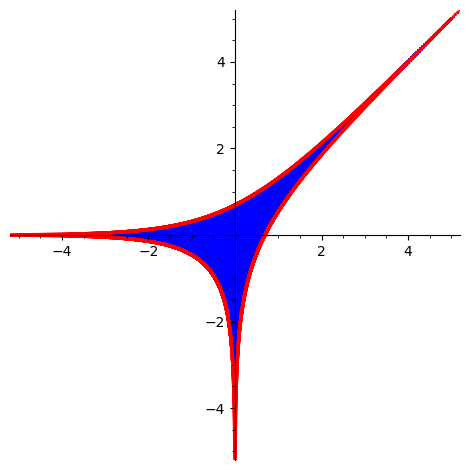

In [15]:
var('x,y')
f = 1-x-y
plot_amoeba(f, 200, 200) + plot_contour(f)

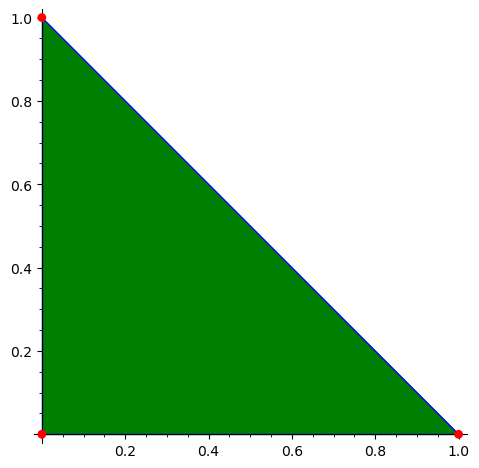

In [16]:
plot_newton_integral_points(f)

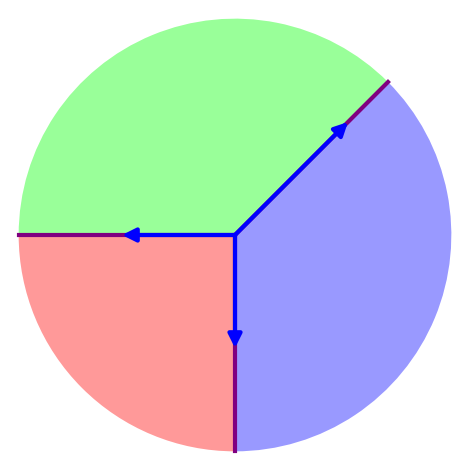

In [17]:
Newton_dual_fan(f)

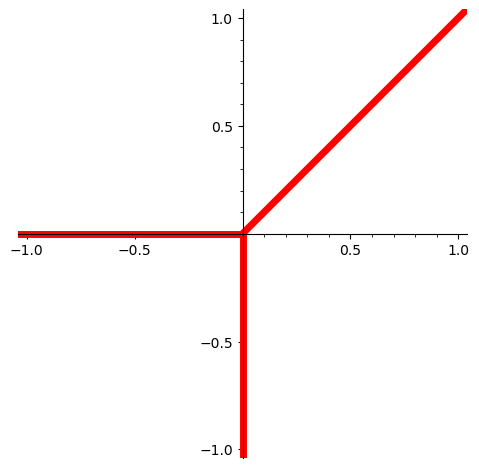

In [18]:
tropical_variety(f)

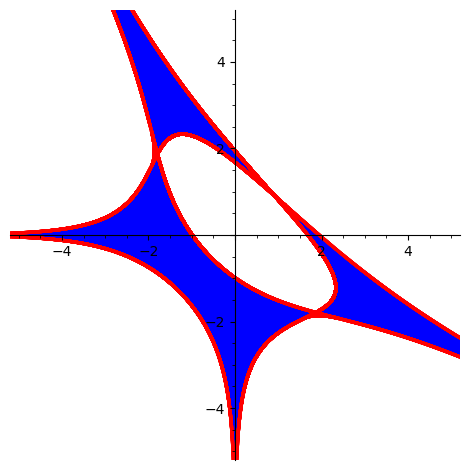

In [19]:
f = 1 - x - y - 6*x*y - x^2*y^2
plot_amoeba(f, 200, 200) + plot_contour(f)

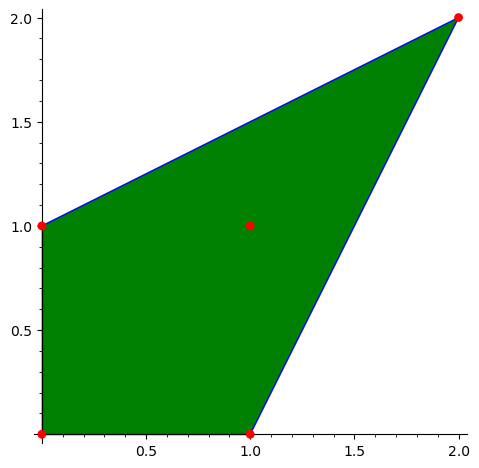

In [20]:
plot_newton_integral_points(f)

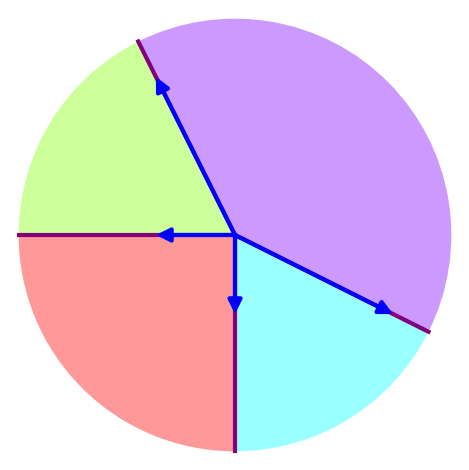

In [21]:
Newton_dual_fan(f)

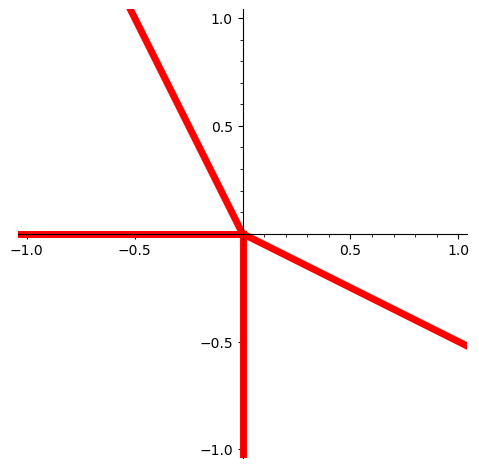

In [22]:
tropical_variety(f)

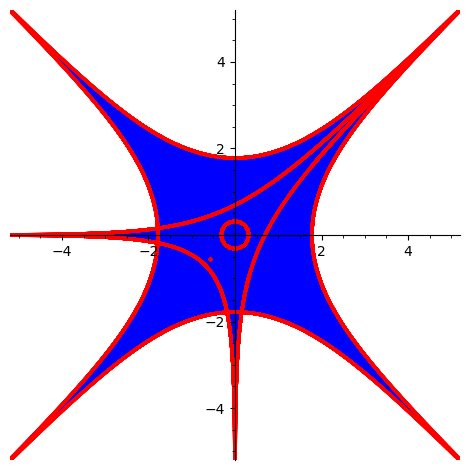

In [23]:
f = (x^2*y + x*y^2 + x + y + 41/10*x*y)*(1+x+y)
plot_amoeba(f, 200, 200) + plot_contour(f)

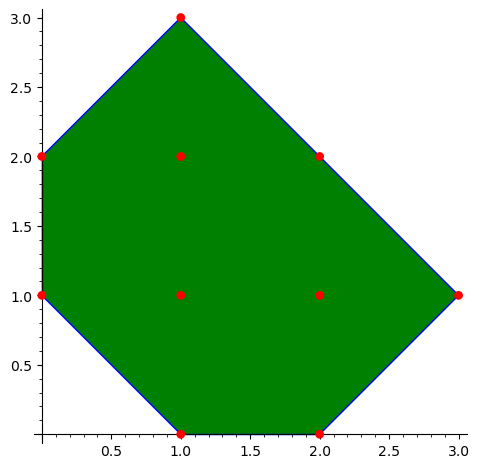

In [24]:
plot_newton_integral_points(f)

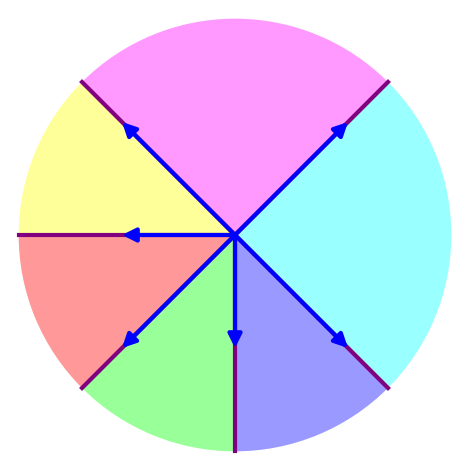

In [25]:
Newton_dual_fan(f)

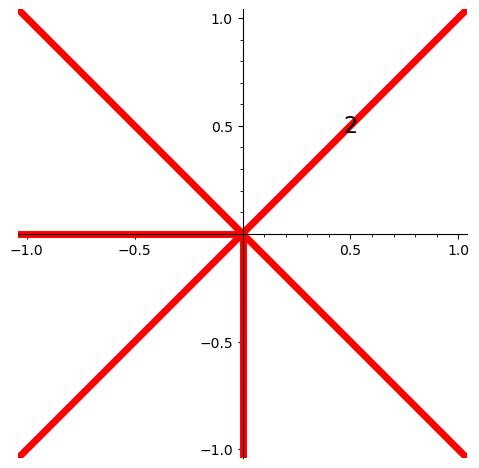

In [26]:
tropical_variety(f)

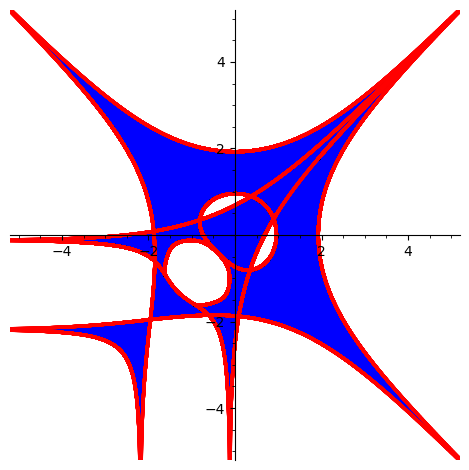

In [27]:
f = 1 + 10*(x^2*y + x*y^2 + x + y + 5*x*y)*(1+x+y)
plot_amoeba(f, 200, 200) + plot_contour(f)

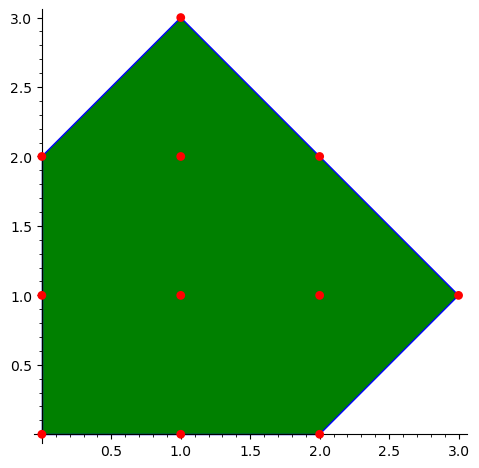

In [28]:
plot_newton_integral_points(f)

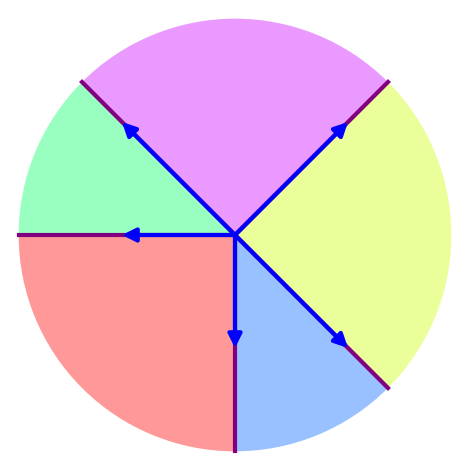

In [29]:
Newton_dual_fan(f)

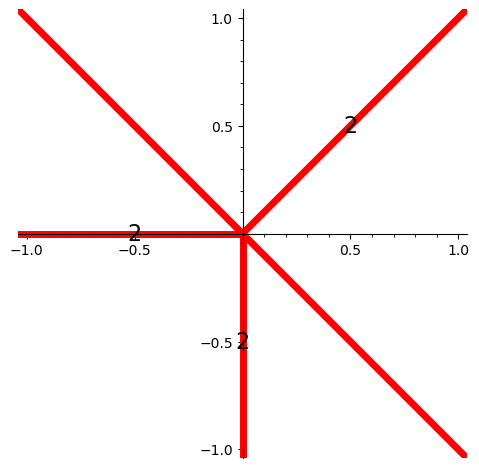

In [30]:
tropical_variety(f)

### Part 3: Properties of Rational Diagonals

In [31]:
# Compute minimal polynomial of central binomial coefficients
from sage_acsv.algebraic import algebraic_diagonal
var('x y')
algebraic_diagonal(1 / (1 - x - y))

(t - 1/4)*y^2 + 1/4

In [32]:
# Compute minimal polynomial for balanced multiset problem
P = algebraic_diagonal(1/(1-x)/(1-y)/(1-x^2*y)/(1-x*y^2))
P.factor()

((t^5 - 2*t^4 + t^3 - t^2 + 2*t - 1)*y - t - 1) * ((t^5 - 2*t^4 + t^3 - t^2 + 2*t - 1)*y + t + 1) * ((t^6 - t^5 - t^4 + t^2 + t - 1)*y - t^2 - 1) * ((t^6 - t^5 - t^4 + t^2 + t - 1)*y + t^2 + 1)

In [33]:
# Catalan rational embedding 1
P = x*(y+1)^2-y
R = y^2*(P.derivative(y)/P).subs(x=x*y).factor()
R

(2*x*y^2 + 2*x*y - 1)*y/(x*y^2 + 2*x*y + x - 1)

In [34]:
# Catalan rational embedding 2
P = y^2 - y + x
R = y^2*(P.derivative(y)/P).subs(x=x*y).factor()
R

(2*y - 1)*y/(x + y - 1)

In [35]:
# Rational embedding for binary trees by vertices and leaves
var('u z y')
P = u*z + 2*z*y + z*y^2 - y
R = y^2*(P.derivative(y)/P).subs(z=z*y,u=u*y).factor()
R

(2*y^2*z + 2*y*z - 1)*y/(u*y*z + y^2*z + 2*y*z - 1)

In [36]:
# Check we match terms computed above
R_pol = QQ[u,z,y](R.taylor([u,y,z],0,10))
QQ[u,z]({exp[0:2]: coeff for exp, coeff in R_pol.dict().items() if exp[2] == exp[0] + exp[1]})

u^2*z^3 + 8*u*z^4 + 4*u*z^3 + 2*u*z^2 + u*z

In [37]:
# Example of 1D resolution of singularities
# First compute how many terms are needed
var('x, y')
f = x*sqrt(1-x)
P = y^2 - x^2*(1-x)
P.resultant(P.derivative(y),y).factor()

4*(x - 1)*x^2

In [38]:
# Then compute the terms up to that order
f.series(x,3)

1*x + (-1/2)*x^2 + Order(x^3)

In [39]:
# Make the substitution 
P.subs(y=x-x^2/2+x^2*y).factor()

1/4*(4*x*y^2 - 4*x*y + x + 8*y)*x^3

In [40]:
# Define Q and compute the rational function R
Q = 4*x*y^2 - 4*x*y + x + 8*y
R = x*y - (x*y)^2/2 + (x*y)^2 * y^2*(Q.derivative(y)/Q).subs(x=x*y).factor()
R

4*(2*x*y^2 - x*y + 2)*x^2*y^3/(4*x*y^2 - 4*x*y + x + 8) - 1/2*x^2*y^2 + x*y

In [41]:
# Compute the diagonal terms of R
terms = (QQ[[x,y]](R.numerator())/QQ[[x,y]](R.denominator())).dict()
diag_terms = {exp[0]: coeff for exp, coeff in terms.items() if exp[1] == exp[0]}
QQ[[x]](diag_terms)

x - 1/2*x^2 - 1/8*x^3 - 1/16*x^4 - 5/128*x^5 - 7/256*x^6

In [42]:
# Check they match the original algebraic function
f.series(x,7)

1*x + (-1/2)*x^2 + (-1/8)*x^3 + (-1/16)*x^4 + (-5/128)*x^5 + (-7/256)*x^6 + Order(x^7)

In [43]:
# General code for embeddings (and the multivariate implementations) coming later this summer
# Email me if you have a problem you would like to look at sooner

In [44]:
# Compute D-finite equation for central binomial coefficients
from sage_periods import compute_diagonal_annihilator as DA
var('x y t')
DA(1/(1-x-y))

(t - 1/4)*Dt + 1/2

In [45]:
# Rigorous NSEW quadrant walks (from diagonal expression)
deq = DA((1+x)*(1+y)/(1-t*x*y*(1/x+x+1/y+y)))
from ore_algebra.analytic.singularity_analysis import bound_coefficients as BC
BC(deq, [1, 2], order=1, prec=20)

1.00000*4^n*(([1.2732 +/- 4.39e-5] + [+/- 2.04e-18]*I)*n^(-1) + B([1678.76 +/- 2.19e-3]*n^(-2)*log(n), n >= 5))

### Formatted plots with black background for slides

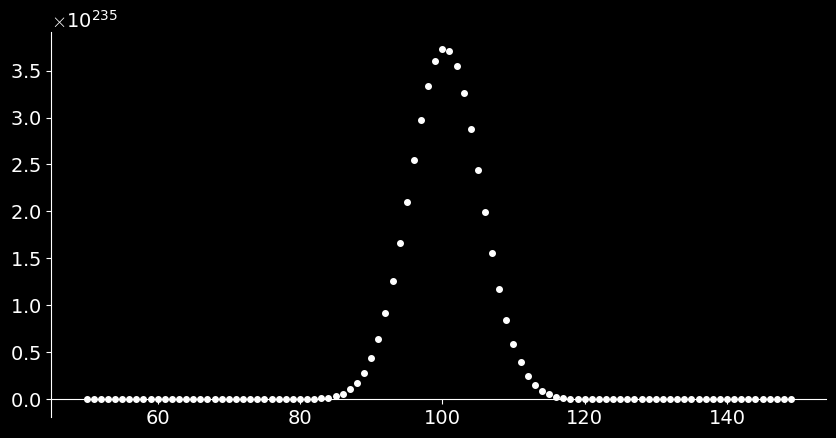

In [45]:
# Instead define series in z whose coeffs are polys in u
S.<u> = QQ['u']
T.<z> = LazyPowerSeriesRing(S)
B = T.undefined()
B.define(u*z + 2*z*B + z*B^2)
B

# Formatted plot for use in slides
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rc('font', size=14)
fig, ax = plt.subplots(figsize=(10, 5), facecolor='black')

# Unpack the list of [x, y] pairs into separate x and y tuples
x_vals, y_vals = zip(*[[k, B[400][k]] for k in range(50, 150)])

# Use ax.plot() with the 'o' format string to plot points
ax.plot(x_vals, y_vals, 'o', color='white', markersize=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.ticklabel_format(style='sci', axis='y', useMathText=True)

plt.show()

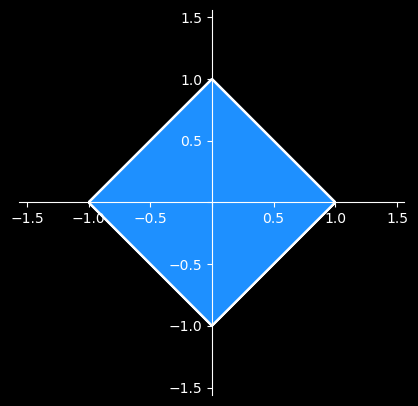

In [46]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rc('font', size=14)

var('x, y')
p = region_plot(
    abs(x) + abs(y) < 1, 
    (x, -1.5, 1.5), 
    (y, -1.5, 1.5), 
    incol='dodgerblue',   # Color of the filled region
    bordercol='white', 
    plot_points=400       # Higher plot_points for a smoother boundary
)

fig = p.matplotlib(figsize=(5, 5))
fig.set_facecolor('black')

ax = fig.axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')
ax.minorticks_off()

fig

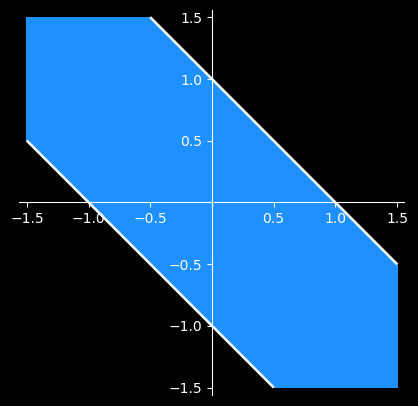

In [47]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rc('font', size=14)

var('x, y')
p = region_plot(
    abs(x+y) < 1, 
    (x, -1.5, 1.5), 
    (y, -1.5, 1.5), 
    incol='dodgerblue',   # Color of the filled region
    bordercol='white', 
    plot_points=400       # Higher plot_points for a smoother boundary
)

fig = p.matplotlib(figsize=(5, 5))
fig.set_facecolor('black')

ax = fig.axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')
ax.minorticks_off()

fig

In [48]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams['savefig.bbox'] = 'standard'

# Apply global formatting styles
plt.style.use('dark_background')
plt.rc('font', size=14)

def plot_amoeba_black(f, n_radius=100, n_theta=100, xmin=-5, xmax=5, ymin=-5, ymax=5):
    """
    Plots the 2D polynomial amoeba of a given two-variable symbolic polynomial f.
    Uses numpy to find roots for efficiency, formatted for dark presentation slides.
    """
    gens = f.variables()
    
    # Cast f into a Polynomial Ring with complex floating point coefficients
    x_name, y_name = str(gens[0]), str(gens[1])
    R = PolynomialRing(CC, names=[x_name, y_name])
    x_poly, y_poly = R.gens()
    f_poly = R(f)
    
    # f_y is a polynomial in y_poly with coefficients in CC[x_poly]
    # f_x is a polynomial in x_poly with coefficients in CC[y_poly]
    coeffs_y = f_poly.polynomial(y_poly).list()
    coeffs_x = f_poly.polynomial(x_poly).list()

    # Use a fixed small value log(almost_zero) to represent -infinity in the amoeba
    almost_zero = 1e-14 
    points = []

    # Pre-generate the grid using meshgrid (vectorization)
    log_r_x = np.linspace(xmin, xmax, n_radius)
    theta = np.linspace(0, 2 * np.pi, n_theta)
    
    LogR, Theta_grid = np.meshgrid(log_r_x, theta)
    LogR_flat = LogR.flatten()
    Z_flat = np.exp(LogR_flat) * np.exp(1j * Theta_grid.flatten())

    # --- Fix x = r*exp(i*theta) and solve for y ---
    C_eval_y = np.zeros((len(Z_flat), len(coeffs_y)), dtype=complex)
    
    for idx, c in enumerate(reversed(coeffs_y)):
        c_list = c.list()
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        C_eval_y[:, idx] = np.polyval(c_np, Z_flat)

    for i in range(len(Z_flat)):
        roots = np.roots(C_eval_y[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            points.append((LogR_flat[i], rho))

    # --- Fix y = r*exp(i*theta) and solve for x ---
    log_r_y = np.linspace(ymin, ymax, n_radius)
    LogR_y, Theta_y_grid = np.meshgrid(log_r_y, theta)
    LogR_y_flat = LogR_y.flatten()
    W_flat = np.exp(LogR_y_flat) * np.exp(1j * Theta_y_grid.flatten())
    
    C_eval_x = np.zeros((len(W_flat), len(coeffs_x)), dtype=complex)
    
    for idx, c in enumerate(reversed(coeffs_x)):
        c_list = c.list()
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        C_eval_x[:, idx] = np.polyval(c_np, W_flat)

    for i in range(len(W_flat)):
        roots = np.roots(C_eval_x[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            points.append((rho, LogR_y_flat[i]))

    P = list_plot(
        points, size=3, color='dodgerblue', aspect_ratio=1, 
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        axes=False, frame=False
    )
    
    fig = P.matplotlib(figsize=(8, 8))
    fig.set_facecolor('black')
    ax = fig.axes[0]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position('zero')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position('zero')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
    ax.minorticks_off()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    fig.set_facecolor('indigo')
    ax.set_facecolor('indigo')

    return fig

def plot_contour_black(f, N_phi=10000, xmin=-5, xmax=5, ymin=-5, ymax=5):
    """
    Plots the contour of the polynomial amoeba of f.
    Uses symbolic resultants for an exact algebraic intersection.
    Formatted for dark presentation slides.
    """
    gens = f.variables()
        
    x_name, y_name = str(gens[0]), str(gens[1])
    
    R_exact = PolynomialRing(QQ, names=['x', 'y', 'c', 's'])
    f_exact = R_exact(f)
        
    x_sym, y_sym, c_sym, s_sym = R_exact.gens()
    fx_sym = f_exact.derivative(x_sym)
    fy_sym = f_exact.derivative(y_sym)
    
    # g(x,y) ensures the ratio x*f_x / y*f_y is a real number
    # c and s represent cos(phi) and sin(phi) for x*f_x / y*f_y = tan(phi)
    g_sym = x_sym * fx_sym * c_sym - y_sym * fy_sym * s_sym
    
    # Compute the resultant to eliminate y (this is purely algebraic and exact)
    res_y_sym = f_exact.resultant(g_sym, y_sym)
    
    # Map the polynomials into standard Complex Double for fast numerical evaluation
    R_CC = PolynomialRing(CC, names=['x', 'y', 'c', 's'])
    
    # Extract coefficients of the resultant (which depend on angle parameters c, s)
    res_x_poly = res_y_sym.polynomial(x_sym)
    coeffs_funcs = [R_CC(coef) for coef in res_x_poly.list()]
    
    # Extract coefficients of f(x, y) to solve for y once we have x
    f_y_poly = f_exact.polynomial(y_sym)
    f_y_coeffs_funcs = [R_CC(coef) for coef in f_y_poly.list()]
    
    fx_CC = R_CC(fx_sym)
    fy_CC = R_CC(fy_sym)
    
    points = []
    almost_zero = 1e-14
    
    # Sweep phi to cover all possible real numbers t = tan(phi)
    Phis = np.linspace(0, np.pi, N_phi)
    
    for phi in Phis:
        c_val = CC(np.cos(phi))
        s_val = CC(np.sin(phi))
        
        # Evaluate resultant coefficients for this specific angle.
        # R_CC(x, y, c, s) requires positional arguments; we zero out x and y.
        eval_coeffs_x = [complex(coef(0, 0, c_val, s_val)) for coef in reversed(coeffs_funcs)]
        
        # Skip if array is empty or zeroed out
        if not any(abs(c) > 1e-12 for c in eval_coeffs_x):
            continue
            
        # Find all valid complex x-coordinates
        roots_x = np.roots(eval_coeffs_x)
        
        for rx in roots_x:
            rx_K = CC(rx)
            
            # Substitute rx into f(x, y) to find corresponding y-coordinates
            eval_coeffs_y = [complex(coef(rx_K, 0, 0, 0)) for coef in reversed(f_y_coeffs_funcs)]
            
            if not any(abs(c) > 1e-12 for c in eval_coeffs_y):
                continue
                
            roots_y = np.roots(eval_coeffs_y)
            
            # Filter valid pairs
            for ry in roots_y:
                ry_K = CC(ry)
                
                # Directly calculate x*f_x and y*f_y
                fx_val = complex(fx_CC(rx_K, ry_K, 0, 0))
                fy_val = complex(fy_CC(rx_K, ry_K, 0, 0))
                
                x_fx = rx * fx_val
                y_fy = ry * fy_val
                
                # Check cross product to ensure Im(x*f_x / y*f_y) == 0
                cross = x_fx.real * y_fy.imag - x_fx.imag * y_fy.real
                scale = abs(x_fx) * abs(y_fy) + 1e-14
                
                # Threshold filters out mismatched (x, y) roots belonging to different branches
                if abs(cross) / scale < 1e-3:
                    rho_x = np.log(max(abs(rx), almost_zero))
                    rho_y = np.log(max(abs(ry), almost_zero))
                    points.append((rho_x, rho_y))
                    
    P = list_plot(
        points, size=6, color='red', aspect_ratio=1, 
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        axes=False, frame=False
    )
    
    fig = P.matplotlib(figsize=(8, 8))
    ax = fig.axes[0]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position('zero')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position('zero')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
    ax.minorticks_off()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    return fig

def plot_amoeba_and_contour_black(f, n_radius=100, n_theta=100, N_phi=10000, xmin=-5, xmax=5, ymin=-5, ymax=5):
    """
    Plots the 2D polynomial amoeba and its exact algebraic contour superimposed.
    Uses numpy for the amoeba roots and symbolic resultants for the contour.
    Formatted for dark presentation slides.
    """
    gens = f.variables()
    
    x_name, y_name = str(gens[0]), str(gens[1])
    almost_zero = 1e-14 
    
    # ==========================================
    # COMPUTE AMOEBA POINTS (Dodgerblue)
    # ==========================================
    R_amoeba = PolynomialRing(CC, names=[x_name, y_name])
    x_poly, y_poly = R_amoeba.gens()
    f_poly = R_amoeba(f)
    
    coeffs_y = f_poly.polynomial(y_poly).list()
    coeffs_x = f_poly.polynomial(x_poly).list()

    amoeba_points = []

    log_r_x = np.linspace(xmin, xmax, n_radius)
    theta = np.linspace(0, 2 * np.pi, n_theta)
    
    LogR, Theta_grid = np.meshgrid(log_r_x, theta)
    LogR_flat = LogR.flatten()
    Z_flat = np.exp(LogR_flat) * np.exp(1j * Theta_grid.flatten())

    C_eval_y = np.zeros((len(Z_flat), len(coeffs_y)), dtype=complex)
    for idx, c in enumerate(reversed(coeffs_y)):
        c_list = c.list()
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        C_eval_y[:, idx] = np.polyval(c_np, Z_flat)

    for i in range(len(Z_flat)):
        roots = np.roots(C_eval_y[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            amoeba_points.append((LogR_flat[i], rho))

    log_r_y = np.linspace(ymin, ymax, n_radius)
    LogR_y, Theta_y_grid = np.meshgrid(log_r_y, theta)
    LogR_y_flat = LogR_y.flatten()
    W_flat = np.exp(LogR_y_flat) * np.exp(1j * Theta_y_grid.flatten())
    
    C_eval_x = np.zeros((len(W_flat), len(coeffs_x)), dtype=complex)
    for idx, c in enumerate(reversed(coeffs_x)):
        c_list = c.list()
        c_np = np.array([complex(coef) for coef in reversed(c_list)]) if c_list else np.array([0j])
        C_eval_x[:, idx] = np.polyval(c_np, W_flat)

    for i in range(len(W_flat)):
        roots = np.roots(C_eval_x[i])
        rhos = np.log(np.maximum(np.abs(roots), almost_zero))
        for rho in rhos:
            amoeba_points.append((rho, LogR_y_flat[i]))

    # ==========================================
    # COMPUTE CONTOUR POINTS (Red)
    # ==========================================
    R_exact = PolynomialRing(QQ, names=['x', 'y', 'c', 's'])
    f_exact = R_exact(f)
        
    x_sym, y_sym, c_sym, s_sym = R_exact.gens()
    fx_sym = f_exact.derivative(x_sym)
    fy_sym = f_exact.derivative(y_sym)
    
    g_sym = x_sym * fx_sym * c_sym - y_sym * fy_sym * s_sym
    res_y_sym = f_exact.resultant(g_sym, y_sym)
    
    R_CC = PolynomialRing(CC, names=['x', 'y', 'c', 's'])
    res_x_poly = res_y_sym.polynomial(x_sym)
    coeffs_funcs = [R_CC(coef) for coef in res_x_poly.list()]
    
    f_y_poly = f_exact.polynomial(y_sym)
    f_y_coeffs_funcs = [R_CC(coef) for coef in f_y_poly.list()]
    
    fx_CC = R_CC(fx_sym)
    fy_CC = R_CC(fy_sym)
    
    contour_points = []
    Phis = np.linspace(0, np.pi, N_phi)
    
    for phi in Phis:
        c_val = CC(np.cos(phi))
        s_val = CC(np.sin(phi))
        
        eval_coeffs_x = [complex(coef(0, 0, c_val, s_val)) for coef in reversed(coeffs_funcs)]
        
        if not any(abs(c) > 1e-12 for c in eval_coeffs_x):
            continue
            
        roots_x = np.roots(eval_coeffs_x)
        
        for rx in roots_x:
            rx_K = CC(rx)
            eval_coeffs_y = [complex(coef(rx_K, 0, 0, 0)) for coef in reversed(f_y_coeffs_funcs)]
            
            if not any(abs(c) > 1e-12 for c in eval_coeffs_y):
                continue
                
            roots_y = np.roots(eval_coeffs_y)
            
            for ry in roots_y:
                ry_K = CC(ry)
                fx_val = complex(fx_CC(rx_K, ry_K, 0, 0))
                fy_val = complex(fy_CC(rx_K, ry_K, 0, 0))
                
                x_fx = rx * fx_val
                y_fy = ry * fy_val
                
                cross = x_fx.real * y_fy.imag - x_fx.imag * y_fy.real
                scale = abs(x_fx) * abs(y_fy) + 1e-14
                
                if abs(cross) / scale < 1e-3:
                    rho_x = np.log(max(abs(rx), almost_zero))
                    rho_y = np.log(max(abs(ry), almost_zero))
                    contour_points.append((rho_x, rho_y))

    # ==========================================
    # MERGE AND RENDER PLOTS
    # ==========================================
    P_amoeba = list_plot(
        amoeba_points, size=3, color='dodgerblue', aspect_ratio=1, 
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        axes=False, frame=False
    )
    
    P_contour = list_plot(
        contour_points, size=6, color='red', aspect_ratio=1, 
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        axes=False, frame=False
    )
    
    P = P_amoeba + P_contour
    fig = P.matplotlib(figsize=(8, 8))
    fig.set_facecolor('black')
    ax = fig.axes[0]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position('zero')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position('zero')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
    ax.minorticks_off()

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    fig.set_facecolor('indigo')
    ax.set_facecolor('indigo')
    
    return fig

def tropical_variety_black(f):
    gens = f.variables()
    var_names = [str(g) for g in gens]
    
    R_classical = PolynomialRing(QQ, names=var_names)
    f_classical = R_classical(f)
    
    # Set up the Tropical Semiring and corresponding Polynomial Ring
    T = TropicalSemiring(QQ, False)
    R_trop = PolynomialRing(T, names=var_names)
    
    # Map to tropical values
    trop_dict = {}
    for degrees, coeff in f_classical.dict().items():
        trop_dict[degrees] = T(0)
            
    # Construct the tropical plot
    trop_plot = R_trop(trop_dict).tropical_variety().plot()
    
    filtered_objects = []
    for primitive in trop_plot:
        if type(primitive).__name__ == 'Text':
            continue
            
        opts = primitive.options()
        if 'thickness' in opts:
            opts['thickness'] = 5
            primitive.set_options(opts)
            
        filtered_objects.append(primitive)
        
    trop_plot._objects = filtered_objects
    trop_plot.axes(False)
    fig = trop_plot.matplotlib()
    
    fig.patch.set_facecolor('black')
    for ax in fig.axes:
        ax.set_facecolor('black')
        ax.axis('off')
        
    return fig

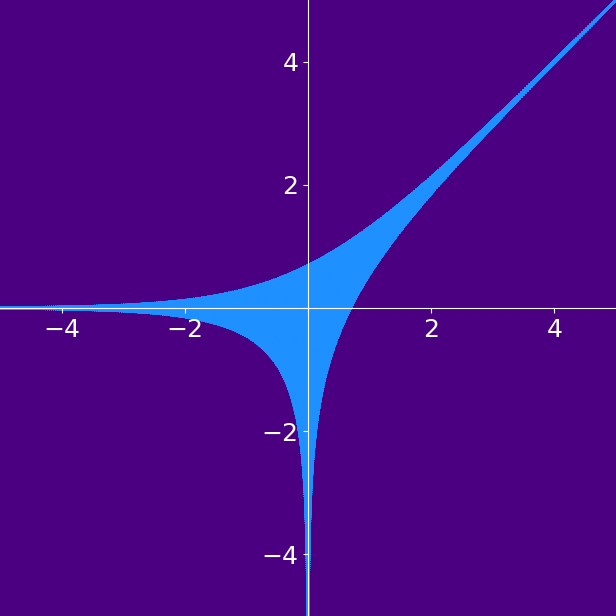

In [49]:
var('x,y')
f = 1-x-y
plot_amoeba_black(f, 300, 300)

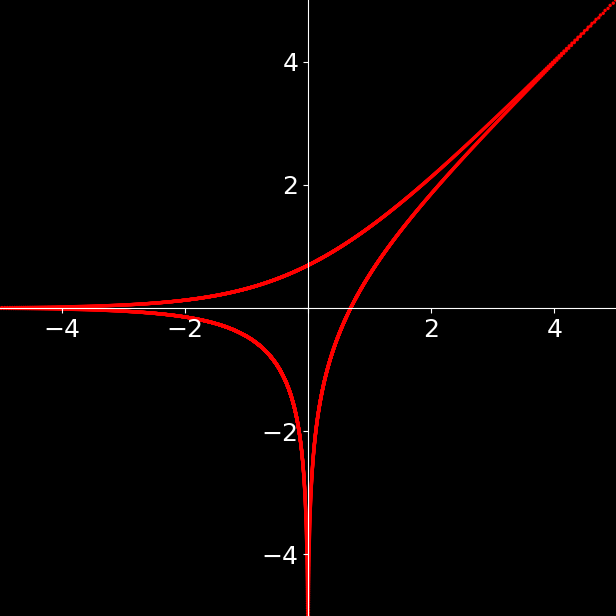

In [50]:
plot_contour_black(f)

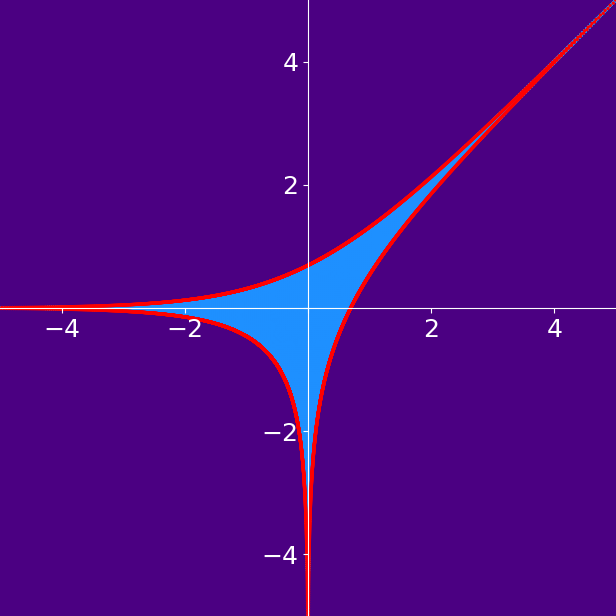

In [51]:
plot_amoeba_and_contour_black(f, 300, 300)

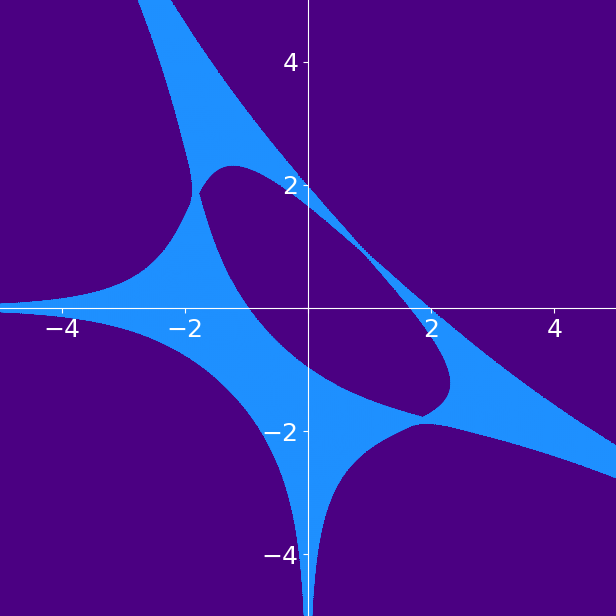

In [52]:
f = 1 - x - y - 6*x*y - x^2*y^2
plot_amoeba_black(f, 300, 300)

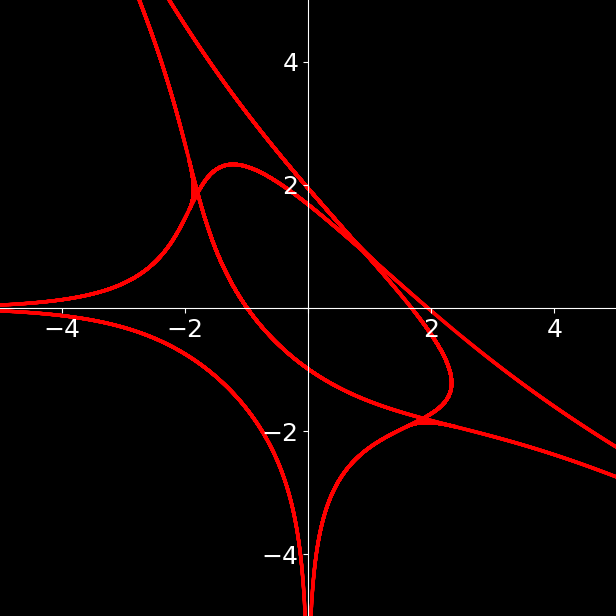

In [53]:
plot_contour_black(f)

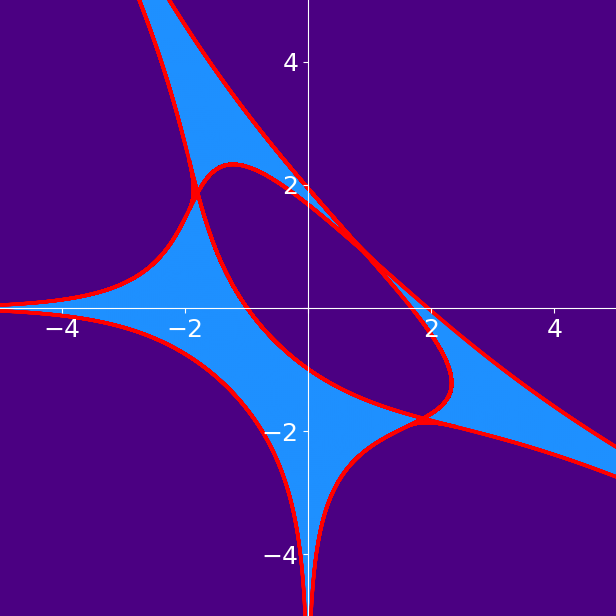

In [54]:
plot_amoeba_and_contour_black(f, 300, 300)

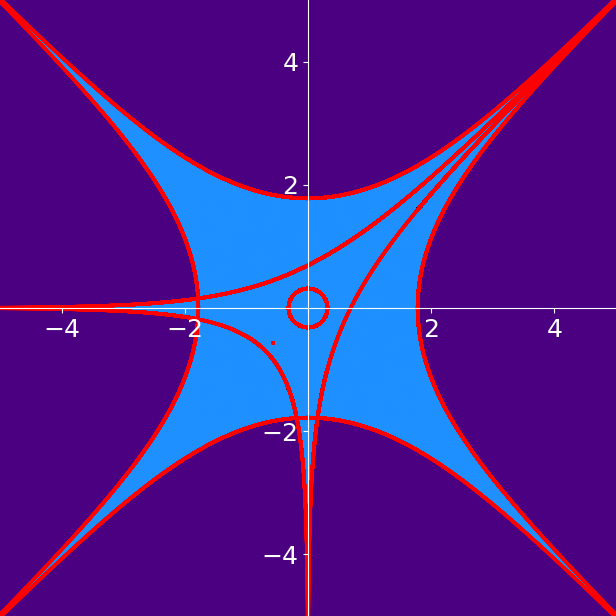

In [55]:
f = (x^2*y + x*y^2 + x + y + 41/10*x*y)*(1+x+y)
plot_amoeba_and_contour_black(f, 300, 300, 10000)

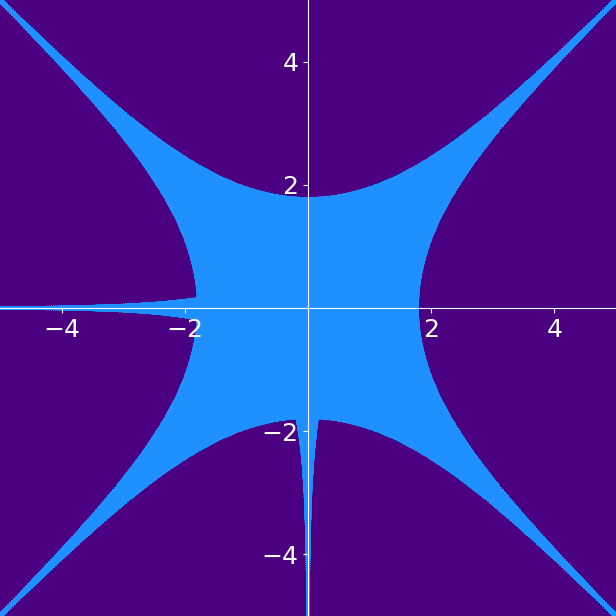

In [56]:
plot_amoeba_black(f, 300, 300)

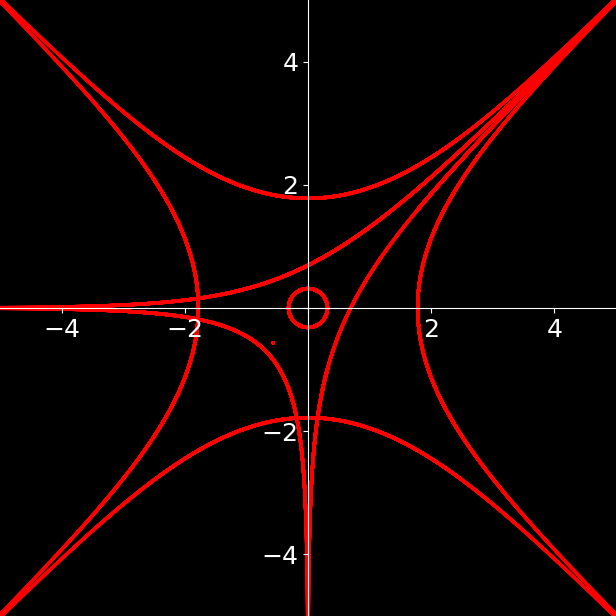

In [57]:
# Note there is an extra dot which comes from numerical error
plot_contour_black(f)

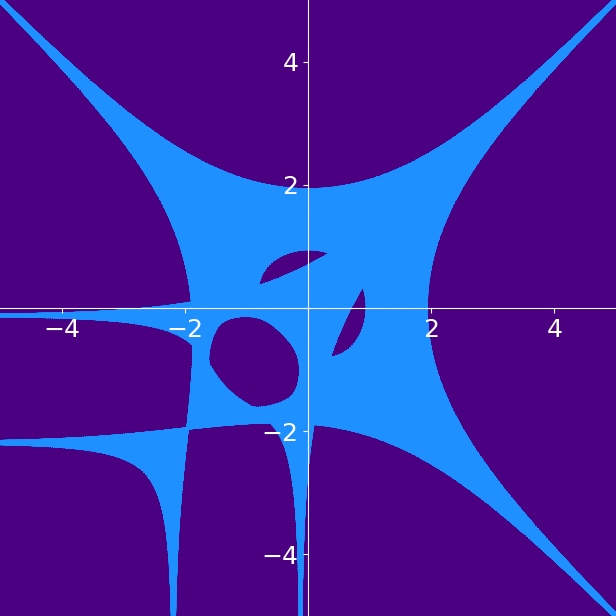

In [58]:
f = 1 + 10*(x^2*y + x*y^2 + x + y + 5*x*y)*(1+x+y)
plot_amoeba_black(f, 300, 300)

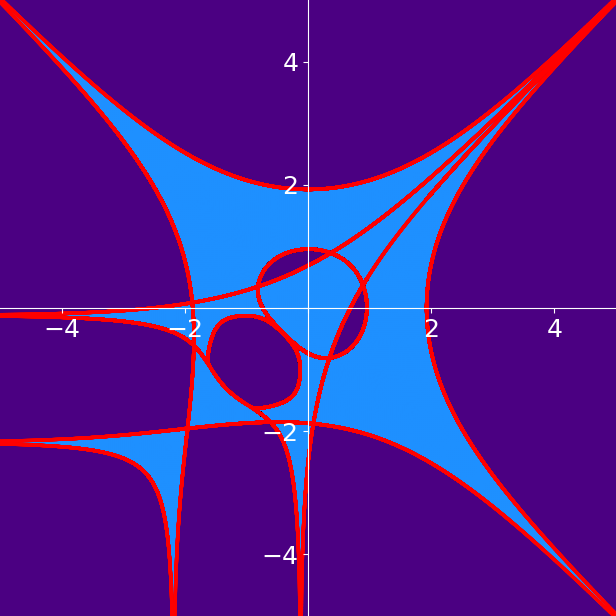

In [59]:
f = 1 + 10*(x^2*y + x*y^2 + x + y + 5*x*y)*(1+x+y)
plot_amoeba_and_contour_black(f, 300, 300, 10000)

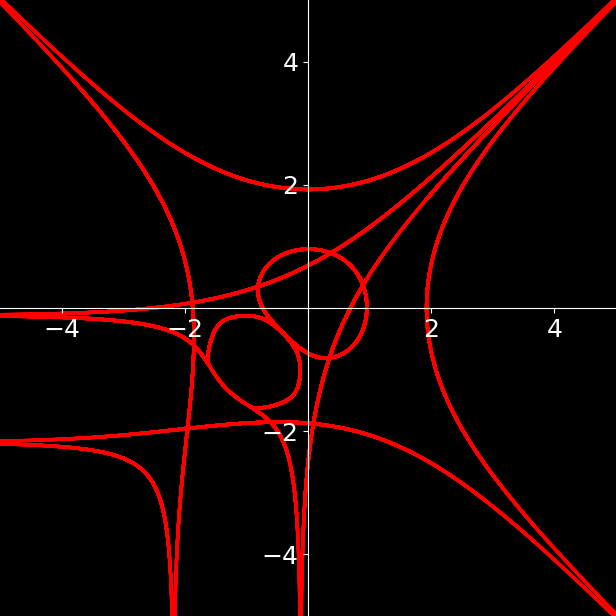

In [60]:
plot_contour_black(f)

In [61]:
import matplotlib.pyplot as plt

def plot_newton_polytope_integral_points_black(H, figsize=(5, 5)):
    plt.style.use('dark_background')
    plt.rc('font', size=14)

    R = PolynomialRing(QQ, names=H.variables())
    poly = R(H)

    exponents = list(poly.dict().keys())
    P = Polyhedron(vertices=exponents)
    int_points = P.integral_points()

    x_coords = [p[0] for p in int_points]
    y_coords = [p[1] for p in int_points]

    min_x, max_x = int(min(x_coords)), int(max(x_coords))
    min_y, max_y = int(min(y_coords)), int(max(y_coords))

    x_ticks = list(range(min_x, max_x + 1))
    y_ticks = list(range(min_y, max_y + 1))

    poly_plot = P.plot(
        polygon={'color': 'dodgerblue'},
        point=False,
        ticks=[x_ticks, y_ticks]
    )

    pts_plot = point2d(
        int_points,
        color='red',
        size=150,
        zorder=10
    )

    combined_plot = poly_plot + pts_plot

    # Prevent clipping on the outer edge
    padding = 0.1
    ghost_anchors = point2d(
        [
            (min_x - padding, min_y - padding),
            (max_x + padding, max_y + padding)
        ],
        alpha=0,
        size=0,
        zorder=-1
    )

    combined_plot += ghost_anchors

    # Convert Sage graphics object to a Matplotlib figure
    fig = combined_plot.matplotlib(figsize=figsize)
    fig.set_facecolor('black')

    label_size = 18
    ax = fig.axes[0]
    ax.set_facecolor('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.minorticks_off()

    return fig

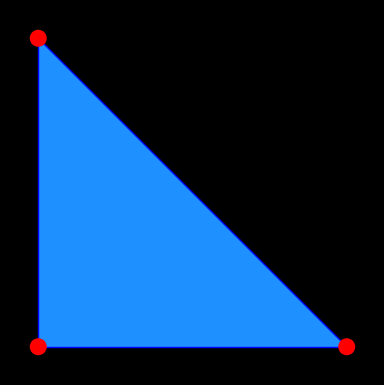

In [62]:
f = 1 - x - y
plot_newton_polytope_integral_points_black(f)

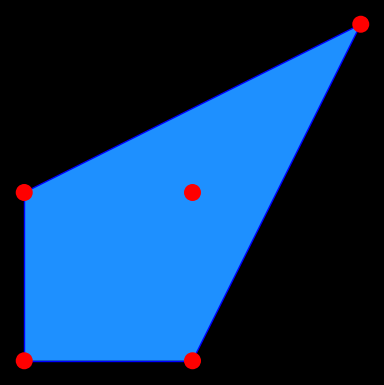

In [63]:
f = 1 - x - y - 6*x*y - x^2*y^2
plot_newton_polytope_integral_points_black(f)

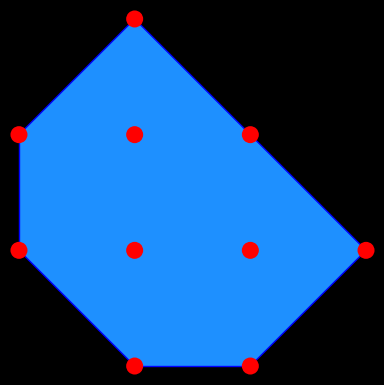

In [64]:
f = (x^2*y + x*y^2 + x + y + 41/10*x*y)*(1+x+y)
plot_newton_polytope_integral_points_black(f)

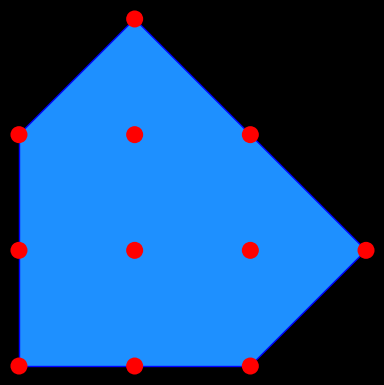

In [65]:
f = 1 + 10*(x^2*y + x*y^2 + x + y + 5*x*y)*(1+x+y)
plot_newton_polytope_integral_points_black(f)

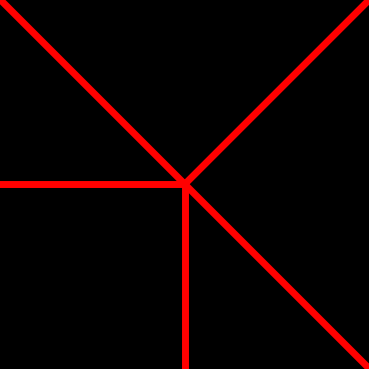

In [66]:
tropical_variety_black(f)